# Advancing Data Security in Global
Banking: Innovative Big Data
Management Techniques
# MSc Data Science | University of Hertfordshire
# Supriya | 23070872


# Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)

import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully.")


All libraries imported successfully.


# Load Dataset

In [ ]:
file_path = '/content/default of credit card clients.xls'

df = pd.read_excel(file_path, header=1, engine='xlrd')
df.columns = [col.strip().replace(' ', '_') for col in df.columns]

print("Dataset loaded successfully.")
print("Shape:", df.shape)
df.head()

Dataset loaded successfully.
Shape: (30000, 25)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default_payment_next_month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


# Basic Dataset Overview

In [ ]:
print("Dataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum().sum(), "missing values found.")

print("\nSummary Statistics:")
print(df.describe().round(2))


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-null  int

# Exploratory Data Analysis (EDA)

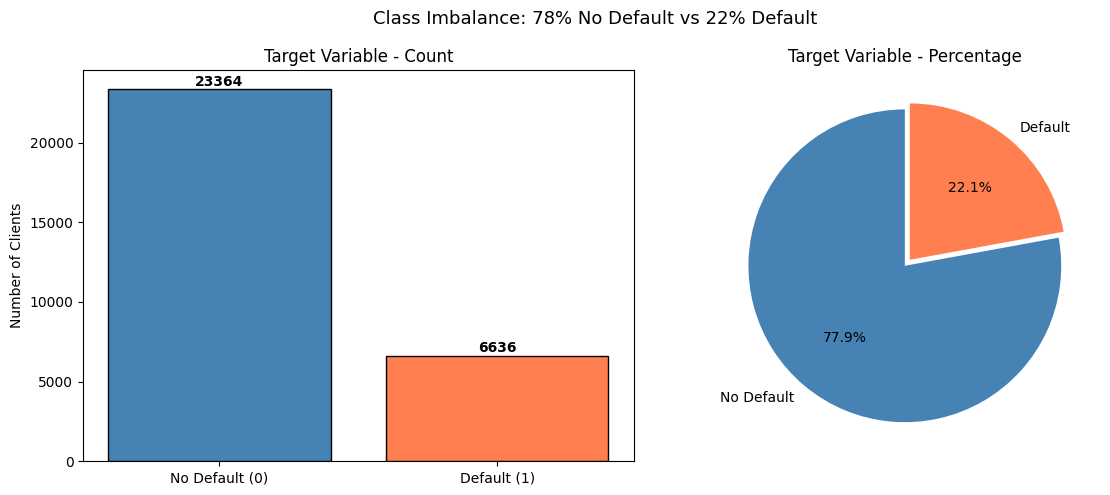

In [ ]:
# --- Plot 1: Target Variable Distribution ---
# This shows the class imbalance in the dataset.
# About 78% of clients did NOT default and 22% did.
# This imbalance means accuracy alone is misleading as a metric.
target_counts = df['default_payment_next_month'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(['No Default (0)', 'Default (1)'],
            [target_counts[0], target_counts[1]],
            color=['steelblue', 'coral'], edgecolor='black')
axes[0].set_title('Target Variable - Count')
axes[0].set_ylabel('Number of Clients')
for i, v in enumerate([target_counts[0], target_counts[1]]):
    axes[0].text(i, v + 200, str(v), ha='center', fontweight='bold')

axes[1].pie([target_counts[0], target_counts[1]],
            labels=['No Default', 'Default'],
            autopct='%1.1f%%',
            colors=['steelblue', 'coral'],
            startangle=90,
            explode=(0, 0.05))
axes[1].set_title('Target Variable - Percentage')

plt.suptitle('Class Imbalance: 78% No Default vs 22% Default', fontsize=13)
plt.tight_layout()
plt.show()

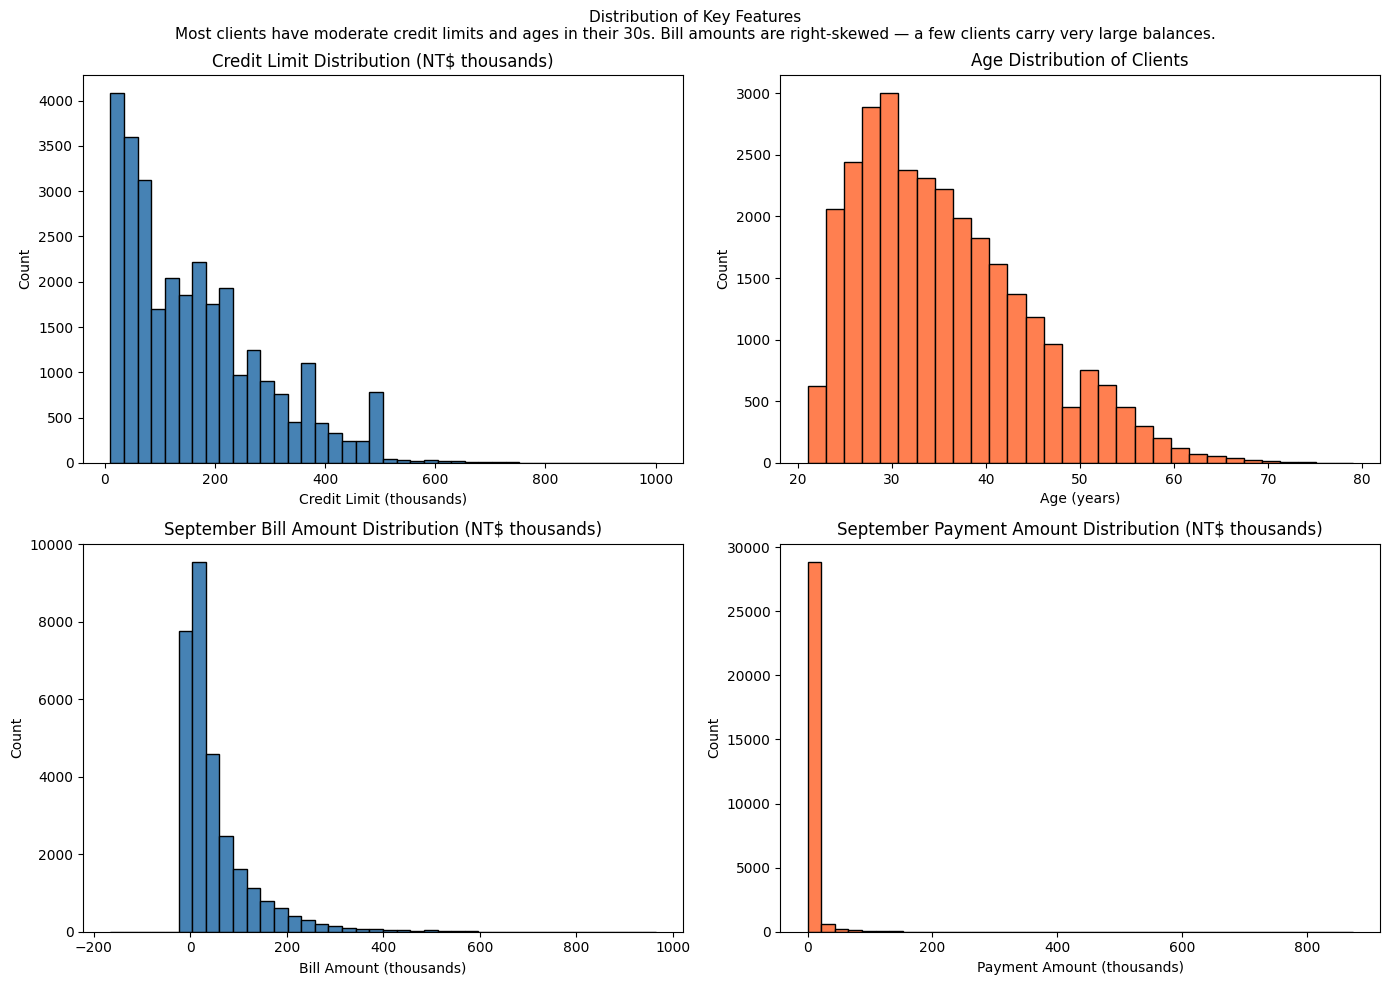

In [ ]:
# --- Plot 2: Distribution of Key Numeric Features ---
# Histograms show how credit limit, age, bill amount,
# and payment amount are distributed across the dataset.
# These give a sense of the typical client profile.
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(df['LIMIT_BAL'] / 1000, bins=40,
                color='steelblue', edgecolor='black')
axes[0, 0].set_title('Credit Limit Distribution (NT$ thousands)')
axes[0, 0].set_xlabel('Credit Limit (thousands)')
axes[0, 0].set_ylabel('Count')

axes[0, 1].hist(df['AGE'], bins=30,
                color='coral', edgecolor='black')
axes[0, 1].set_title('Age Distribution of Clients')
axes[0, 1].set_xlabel('Age (years)')
axes[0, 1].set_ylabel('Count')

axes[1, 0].hist(df['BILL_AMT1'] / 1000, bins=40,
                color='steelblue', edgecolor='black')
axes[1, 0].set_title('September Bill Amount Distribution (NT$ thousands)')
axes[1, 0].set_xlabel('Bill Amount (thousands)')
axes[1, 0].set_ylabel('Count')

axes[1, 1].hist(df['PAY_AMT1'] / 1000, bins=40,
                color='coral', edgecolor='black')
axes[1, 1].set_title('September Payment Amount Distribution (NT$ thousands)')
axes[1, 1].set_xlabel('Payment Amount (thousands)')
axes[1, 1].set_ylabel('Count')

plt.suptitle('Distribution of Key Features\n'
             'Most clients have moderate credit limits and ages in their 30s. '
             'Bill amounts are right-skewed — a few clients carry very large balances.',
             fontsize=11)
plt.tight_layout()
plt.show()

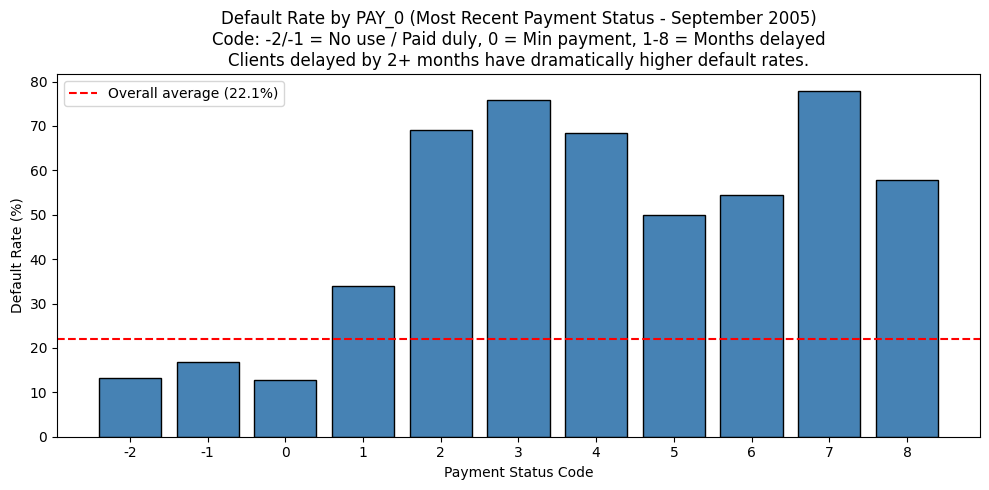

In [ ]:
# --- Plot 3: Default Rate by Payment Status (PAY_0) ---
# PAY_0 is the most recent repayment status (September 2005).
# Clients with payment delays of 2+ months have much higher default rates.
# This is the single strongest predictor of default in the dataset.
pay0_dr = df.groupby('PAY_0')['default_payment_next_month'].mean() * 100
overall_dr = df['default_payment_next_month'].mean() * 100

plt.figure(figsize=(10, 5))
plt.bar(pay0_dr.index.astype(str), pay0_dr.values,
        color='steelblue', edgecolor='black')
plt.axhline(y=overall_dr, color='red', linestyle='--',
            label=f'Overall average ({overall_dr:.1f}%)')
plt.title('Default Rate by PAY_0 (Most Recent Payment Status - September 2005)\n'
          'Code: -2/-1 = No use / Paid duly, 0 = Min payment, 1-8 = Months delayed\n'
          'Clients delayed by 2+ months have dramatically higher default rates.')
plt.xlabel('Payment Status Code')
plt.ylabel('Default Rate (%)')
plt.legend()
plt.tight_layout()
plt.show()

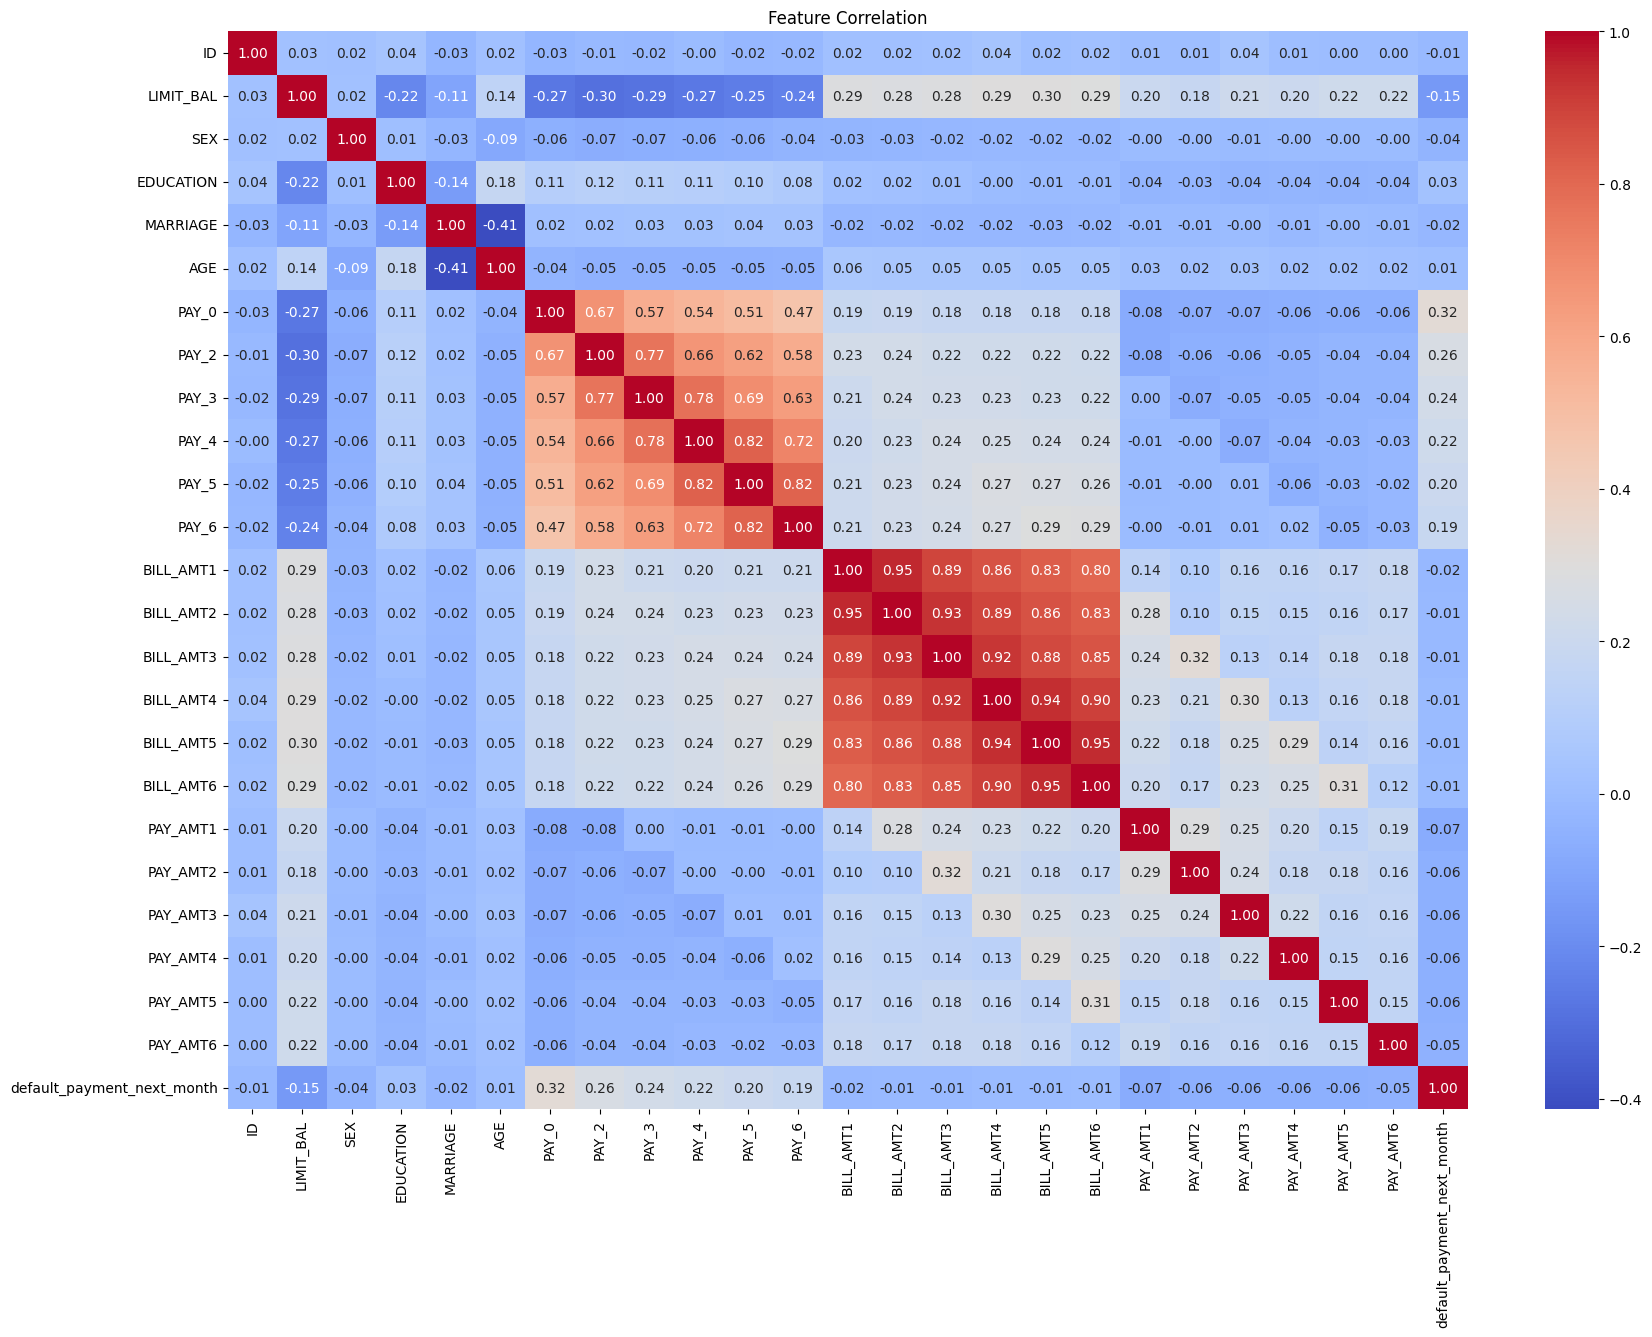

Top 10 Features Correlated with Default:
PAY_0        0.324794
PAY_2        0.263551
PAY_3        0.235253
PAY_4        0.216614
PAY_5        0.204149
PAY_6        0.186866
LIMIT_BAL    0.153520
PAY_AMT1     0.072929
PAY_AMT2     0.058579
PAY_AMT4     0.056827
Name: default_payment_next_month, dtype: float64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Plot 4: Correlation Heatmap ---
# The heatmap shows relationships between all features.
# Key findings:
# - PAY_0 has the highest correlation with the target (0.32)
# - BILL_AMT1 to BILL_AMT6 are very highly correlated with each other (>0.90),
#   meaning they carry mostly the same information
# - PAY columns are moderately correlated with each other
plt.figure(figsize=(20,14))
corr = df.corr() # Assign the correlation matrix to 'corr'
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation')
plt.show()

# Top features correlated with target
print("Top 10 Features Correlated with Default:")
target_corr = corr['default_payment_next_month'].drop('default_payment_next_month')
print(target_corr.abs().sort_values(ascending=False).head(10))

# Data Cleaning

In [ ]:
# Drop the ID column (not predictive)
df_clean = df.drop(columns=['ID'], errors='ignore').copy()

# Fix irregular category codes:
# EDUCATION: codes 0, 5, 6 are undocumented — merged into category 4 (Others)
# MARRIAGE: code 0 is undocumented — merged into category 3 (Others)
df_clean['EDUCATION'] = df_clean['EDUCATION'].replace({0: 4, 5: 4, 6: 4})
df_clean['MARRIAGE']  = df_clean['MARRIAGE'].replace({0: 3})

print("After Cleaning:")
print("EDUCATION values:", sorted(df_clean['EDUCATION'].unique()))
print("MARRIAGE values:", sorted(df_clean['MARRIAGE'].unique()))
print("Shape:", df_clean.shape)


After Cleaning:
EDUCATION values: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
MARRIAGE values: [np.int64(1), np.int64(2), np.int64(3)]
Shape: (30000, 24)


# Feature Engineering

In [ ]:
# The raw monthly columns tell you what happened each month,
# but do not directly express overall behaviour patterns.
# Nine new features are created to capture:
# - Average and total billing/payment over 6 months
# - Worst and average payment delay across 6 months
# - Repayment coverage relative to total billed
# - Credit utilisation relative to the credit limit
bill_cols       = ['BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6']
pay_amt_cols    = ['PAY_AMT1','PAY_AMT2','PAY_AMT3','PAY_AMT4','PAY_AMT5','PAY_AMT6']
pay_status_cols = ['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']

df_clean['avg_bill_amt']      = df_clean[bill_cols].mean(axis=1)
df_clean['avg_pay_amt']       = df_clean[pay_amt_cols].mean(axis=1)
df_clean['max_bill_amt']      = df_clean[bill_cols].max(axis=1)
df_clean['max_pay_delay']     = df_clean[pay_status_cols].max(axis=1)
df_clean['avg_pay_delay']     = df_clean[pay_status_cols].mean(axis=1)
df_clean['total_bill_amt']    = df_clean[bill_cols].sum(axis=1)
df_clean['total_pay_amt']     = df_clean[pay_amt_cols].sum(axis=1)
df_clean['pay_to_bill_ratio'] = df_clean['total_pay_amt'] / (df_clean['total_bill_amt'] + 1)
df_clean['utilization_ratio'] = df_clean['max_bill_amt'] / (df_clean['LIMIT_BAL'] + 1)

print(f"Features expanded from 24 to {df_clean.shape[1] - 1} after feature engineering.")

Features expanded from 24 to 32 after feature engineering.


# Train-Test Split and Scaling

In [ ]:
X = df_clean.drop('default_payment_next_month', axis=1)
y = df_clean['default_payment_next_month']

# 80/20 stratified split — preserves 78/22 class ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Standard scaling for Logistic Regression (tree models don't need it)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Train size: {X_train.shape[0]}  |  Test size: {X_test.shape[0]}")


Train size: 24000  |  Test size: 6000


# Apply SMOTE to Training Data

In [ ]:
# The training set has ~78% non-defaults and ~22% defaults.
# SMOTE (Synthetic Minority Oversampling Technique) creates
# synthetic examples of the minority class (defaulters) by
# interpolating between existing minority samples.
# This forces models to learn better boundaries for defaulters.
# IMPORTANT: SMOTE is only applied to TRAINING data.
# The test set stays unchanged so evaluation reflects real-world conditions.
print("Before SMOTE:")
print(f"  Non-default: {(y_train==0).sum()}  |  Default: {(y_train==1).sum()}")

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

# Re-scale after SMOTE for logistic regression
X_train_sm_scaled = scaler.fit_transform(X_train_sm)

print("\nAfter SMOTE:")
print(f"  Non-default: {(y_train_sm==0).sum()}  |  Default: {(y_train_sm==1).sum()}")


Before SMOTE:
  Non-default: 18691  |  Default: 5309

After SMOTE:
  Non-default: 18691  |  Default: 18691


# Visualise SMOTE effect

---



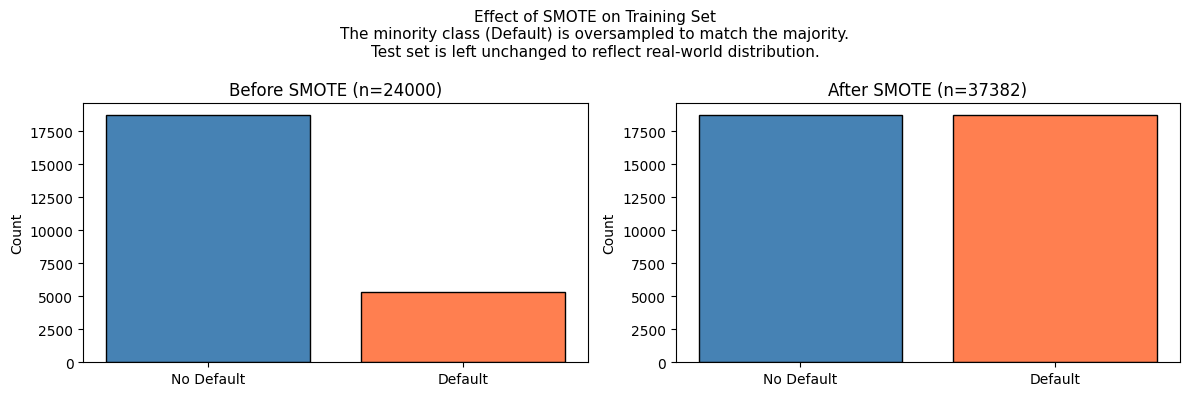

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(['No Default', 'Default'],
            [(y_train==0).sum(), (y_train==1).sum()],
            color=['steelblue', 'coral'], edgecolor='black')
axes[0].set_title(f'Before SMOTE (n={len(y_train)})')
axes[0].set_ylabel('Count')

axes[1].bar(['No Default', 'Default'],
            [(y_train_sm==0).sum(), (y_train_sm==1).sum()],
            color=['steelblue', 'coral'], edgecolor='black')
axes[1].set_title(f'After SMOTE (n={len(y_train_sm)})')
axes[1].set_ylabel('Count')

plt.suptitle('Effect of SMOTE on Training Set\n'
             'The minority class (Default) is oversampled to match the majority.\n'
             'Test set is left unchanged to reflect real-world distribution.',
             fontsize=11)
plt.tight_layout()
plt.show()


# Evaluate Model

In [ ]:
def get_metrics(name, y_true, y_pred):
    return {
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'Recall':    round(recall_score(y_true, y_pred), 4),
        'F1 Score':  round(f1_score(y_true, y_pred), 4),
    }

def show_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    fig, ax = plt.subplots(figsize=(5, 4))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['No Default', 'Default'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(title)
    ax.set_xlabel(f'Predicted\n\nTN={tn}  FP={fp}  FN={fn}  TP={tp}')
    plt.tight_layout()
    plt.show()
    print(f"\nConfusion Matrix — {title}")
    print(f"  True Negatives  (correctly said No Default): {tn}")
    print(f"  False Positives (wrongly flagged as Default): {fp}")
    print(f"  False Negatives (missed actual Defaults):     {fn}  ← costly for the bank")
    print(f"  True Positives  (correctly caught Defaults):  {tp}")
    print(f"  Recall = {tp}/{tp+fn} = {tp/(tp+fn)*100:.1f}% of actual defaulters caught")


# Modeling (Logistic Regression)


Baseline (Without SMOTE):
              precision    recall  f1-score   support

  No Default       0.88      0.75      0.81      4673
     Default       0.42      0.63      0.50      1327

    accuracy                           0.72      6000
   macro avg       0.65      0.69      0.65      6000
weighted avg       0.77      0.72      0.74      6000



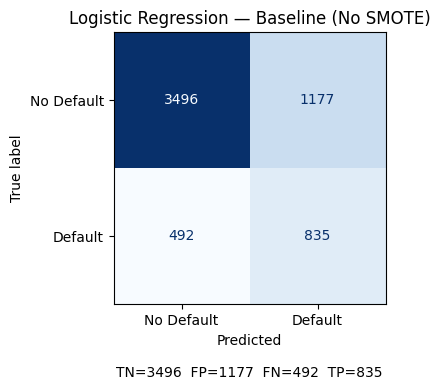


Confusion Matrix — Logistic Regression — Baseline (No SMOTE)
  True Negatives  (correctly said No Default): 3496
  False Positives (wrongly flagged as Default): 1177
  False Negatives (missed actual Defaults):     492  ← costly for the bank
  True Positives  (correctly caught Defaults):  835
  Recall = 835/1327 = 62.9% of actual defaulters caught

Baseline (With SMOTE):
              precision    recall  f1-score   support

  No Default       0.87      0.57      0.69      4673
     Default       0.32      0.71      0.44      1327

    accuracy                           0.60      6000
   macro avg       0.60      0.64      0.56      6000
weighted avg       0.75      0.60      0.63      6000



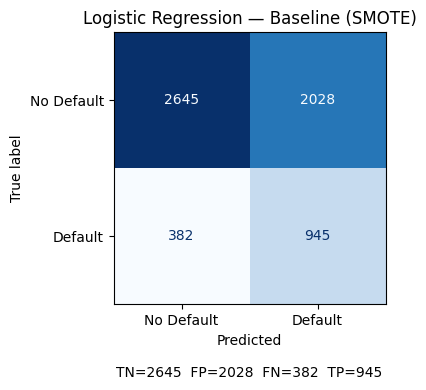


Confusion Matrix — Logistic Regression — Baseline (SMOTE)
  True Negatives  (correctly said No Default): 2645
  False Positives (wrongly flagged as Default): 2028
  False Negatives (missed actual Defaults):     382  ← costly for the bank
  True Positives  (correctly caught Defaults):  945
  Recall = 945/1327 = 71.2% of actual defaulters caught


In [ ]:
# --- Baseline (Without SMOTE) ---
# class_weight='balanced' compensates for imbalance by giving
# more weight to defaulters during training
lr_base = LogisticRegression(class_weight='balanced',
                              max_iter=2000, random_state=42)
lr_base.fit(X_train_scaled, y_train)
lr_base_pred = lr_base.predict(X_test_scaled)

print("\nBaseline (Without SMOTE):")
print(classification_report(y_test, lr_base_pred,
                             target_names=['No Default', 'Default']))
show_confusion_matrix(y_test, lr_base_pred,
                      'Logistic Regression — Baseline (No SMOTE)')

# --- Baseline (With SMOTE) ---
lr_smote = LogisticRegression(max_iter=2000, random_state=42)
lr_smote.fit(X_train_sm_scaled, y_train_sm)
lr_smote_pred = lr_smote.predict(X_test_scaled)

print("\nBaseline (With SMOTE):")
print(classification_report(y_test, lr_smote_pred,
                             target_names=['No Default', 'Default']))
show_confusion_matrix(y_test, lr_smote_pred,
                      'Logistic Regression — Baseline (SMOTE)')

#Random Forest


Baseline (Without SMOTE):
              precision    recall  f1-score   support

  No Default       0.83      0.95      0.89      4673
     Default       0.63      0.33      0.43      1327

    accuracy                           0.81      6000
   macro avg       0.73      0.64      0.66      6000
weighted avg       0.79      0.81      0.79      6000



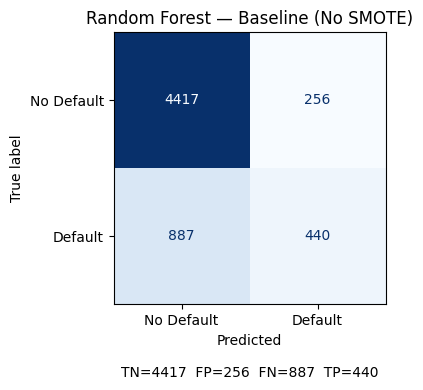


Confusion Matrix — Random Forest — Baseline (No SMOTE)
  True Negatives  (correctly said No Default): 4417
  False Positives (wrongly flagged as Default): 256
  False Negatives (missed actual Defaults):     887  ← costly for the bank
  True Positives  (correctly caught Defaults):  440
  Recall = 440/1327 = 33.2% of actual defaulters caught

Baseline (With SMOTE):
              precision    recall  f1-score   support

  No Default       0.85      0.89      0.87      4673
     Default       0.55      0.46      0.50      1327

    accuracy                           0.80      6000
   macro avg       0.70      0.68      0.69      6000
weighted avg       0.79      0.80      0.79      6000



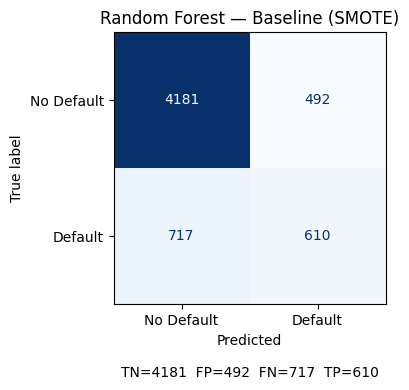


Confusion Matrix — Random Forest — Baseline (SMOTE)
  True Negatives  (correctly said No Default): 4181
  False Positives (wrongly flagged as Default): 492
  False Negatives (missed actual Defaults):     717  ← costly for the bank
  True Positives  (correctly caught Defaults):  610
  Recall = 610/1327 = 46.0% of actual defaulters caught


In [ ]:
# --- Baseline (Without SMOTE) ---
# class_weight='balanced' adjusts weights inversely proportional to class frequency
rf_base = RandomForestClassifier(class_weight='balanced',
                                  random_state=42, n_jobs=-1)
rf_base.fit(X_train, y_train)
rf_base_pred = rf_base.predict(X_test)

print("\nBaseline (Without SMOTE):")
print(classification_report(y_test, rf_base_pred,
                             target_names=['No Default', 'Default']))
show_confusion_matrix(y_test, rf_base_pred,
                      'Random Forest — Baseline (No SMOTE)')

# --- Baseline (With SMOTE) ---
rf_smote = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_smote.fit(X_train_sm, y_train_sm)
rf_smote_pred = rf_smote.predict(X_test)

print("\nBaseline (With SMOTE):")
print(classification_report(y_test, rf_smote_pred,
                             target_names=['No Default', 'Default']))
show_confusion_matrix(y_test, rf_smote_pred,
                      'Random Forest — Baseline (SMOTE)')

#XGBoost


Baseline (Without SMOTE):
              precision    recall  f1-score   support

  No Default       0.87      0.81      0.84      4673
     Default       0.46      0.58      0.51      1327

    accuracy                           0.76      6000
   macro avg       0.67      0.69      0.68      6000
weighted avg       0.78      0.76      0.77      6000



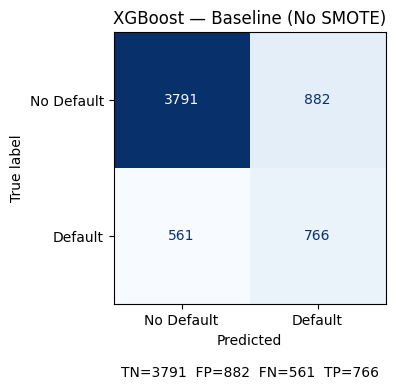


Confusion Matrix — XGBoost — Baseline (No SMOTE)
  True Negatives  (correctly said No Default): 3791
  False Positives (wrongly flagged as Default): 882
  False Negatives (missed actual Defaults):     561  ← costly for the bank
  True Positives  (correctly caught Defaults):  766
  Recall = 766/1327 = 57.7% of actual defaulters caught

Baseline (With SMOTE):
              precision    recall  f1-score   support

  No Default       0.84      0.89      0.87      4673
     Default       0.52      0.43      0.47      1327

    accuracy                           0.78      6000
   macro avg       0.68      0.66      0.67      6000
weighted avg       0.77      0.78      0.78      6000



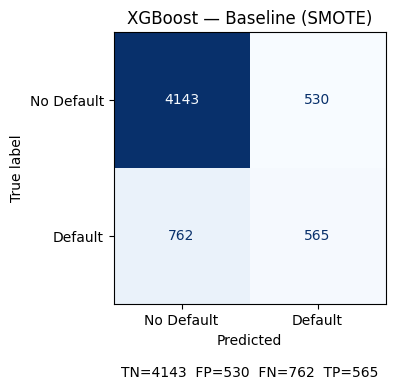


Confusion Matrix — XGBoost — Baseline (SMOTE)
  True Negatives  (correctly said No Default): 4143
  False Positives (wrongly flagged as Default): 530
  False Negatives (missed actual Defaults):     762  ← costly for the bank
  True Positives  (correctly caught Defaults):  565
  Recall = 565/1327 = 42.6% of actual defaulters caught


In [ ]:
# scale_pos_weight compensates for imbalance by telling XGBoost
# how many times more non-defaults there are compared to defaults.
# This shifts focus towards correctly predicting the minority class.
scale_pw = (y_train == 0).sum() / (y_train == 1).sum()

# --- Baseline (Without SMOTE) ---
xgb_base = XGBClassifier(scale_pos_weight=scale_pw,
                           eval_metric='logloss',
                           random_state=42,
                           use_label_encoder=False)
xgb_base.fit(X_train, y_train)
xgb_base_pred = xgb_base.predict(X_test)

print("\nBaseline (Without SMOTE):")
print(classification_report(y_test, xgb_base_pred,
                             target_names=['No Default', 'Default']))
show_confusion_matrix(y_test, xgb_base_pred,
                      'XGBoost — Baseline (No SMOTE)')

# --- Baseline (With SMOTE) ---
# No scale_pos_weight needed — SMOTE already balanced the training data
xgb_smote = XGBClassifier(eval_metric='logloss',
                            random_state=42,
                            use_label_encoder=False)
xgb_smote.fit(X_train_sm, y_train_sm)
xgb_smote_pred = xgb_smote.predict(X_test)

print("\nBaseline (With SMOTE):")
print(classification_report(y_test, xgb_smote_pred,
                             target_names=['No Default', 'Default']))
show_confusion_matrix(y_test, xgb_smote_pred,
                      'XGBoost — Baseline (SMOTE)')

#Hyperparameter Tuning (LogisticRegression)


Hyperparameter Tuning (With SMOTE):
Best Parameters: {'C': 0.01, 'max_iter': 1000, 'solver': 'liblinear'}
Best Cross-Validated F1: 0.7094
              precision    recall  f1-score   support

  No Default       0.87      0.57      0.69      4673
     Default       0.32      0.71      0.44      1327

    accuracy                           0.60      6000
   macro avg       0.59      0.64      0.56      6000
weighted avg       0.75      0.60      0.63      6000



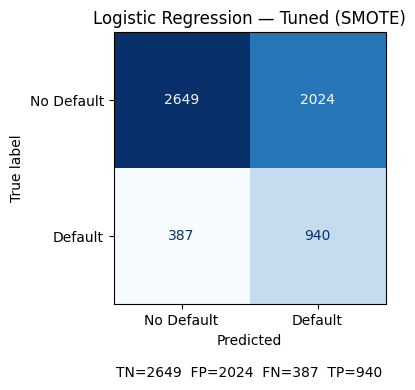


Confusion Matrix — Logistic Regression — Tuned (SMOTE)
  True Negatives  (correctly said No Default): 2649
  False Positives (wrongly flagged as Default): 2024
  False Negatives (missed actual Defaults):     387  ← costly for the bank
  True Positives  (correctly caught Defaults):  940
  Recall = 940/1327 = 70.8% of actual defaulters caught

Logistic Regression Summary:
                   Model  Accuracy  Precision  Recall  F1 Score
LR — Baseline (No SMOTE)    0.7218     0.4150  0.6292    0.5001
   LR — Baseline (SMOTE)    0.5983     0.3179  0.7121    0.4395
      LR — Tuned (SMOTE)    0.5982     0.3171  0.7084    0.4381


In [ ]:
# --- Hyperparameter Tuning (With SMOTE) ---
# Testing different regularisation strengths (C) and solvers.
# A smaller C means stronger regularisation (simpler model).
# GridSearchCV finds the best combination using 3-fold cross-validation.
lr_params = {
    'C':       [0.01, 0.1, 1, 10],
    'solver':  ['lbfgs', 'liblinear'],
    'max_iter': [1000, 2000]
}

lr_grid = GridSearchCV(
    LogisticRegression(random_state=42),
    lr_params,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

lr_grid.fit(X_train_sm_scaled, y_train_sm)
lr_tuned_pred = lr_grid.predict(X_test_scaled)

print("\nHyperparameter Tuning (With SMOTE):")
print("Best Parameters:", lr_grid.best_params_)
print("Best Cross-Validated F1:", round(lr_grid.best_score_, 4))
print(classification_report(y_test, lr_tuned_pred,
                             target_names=['No Default', 'Default']))
show_confusion_matrix(y_test, lr_tuned_pred,
                      'Logistic Regression — Tuned (SMOTE)')

# Store results
lr_results = pd.DataFrame([
    get_metrics('LR — Baseline (No SMOTE)', y_test, lr_base_pred),
    get_metrics('LR — Baseline (SMOTE)',    y_test, lr_smote_pred),
    get_metrics('LR — Tuned (SMOTE)',       y_test, lr_tuned_pred),
])
print("\nLogistic Regression Summary:")
print(lr_results.to_string(index=False))

#Random Forest


Hyperparameter Tuning (With SMOTE):
Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Best Cross-Validated F1: 0.8092
              precision    recall  f1-score   support

  No Default       0.86      0.89      0.87      4673
     Default       0.55      0.47      0.51      1327

    accuracy                           0.80      6000
   macro avg       0.70      0.68      0.69      6000
weighted avg       0.79      0.80      0.79      6000



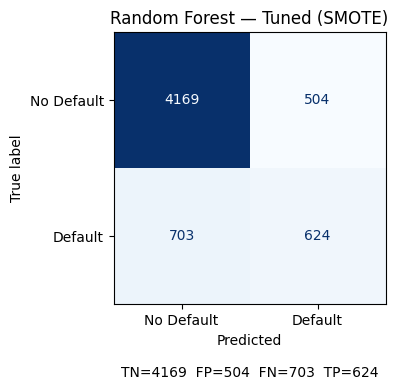


Confusion Matrix — Random Forest — Tuned (SMOTE)
  True Negatives  (correctly said No Default): 4169
  False Positives (wrongly flagged as Default): 504
  False Negatives (missed actual Defaults):     703  ← costly for the bank
  True Positives  (correctly caught Defaults):  624
  Recall = 624/1327 = 47.0% of actual defaulters caught

Random Forest Summary:
                   Model  Accuracy  Precision  Recall  F1 Score
RF — Baseline (No SMOTE)    0.8095     0.6322  0.3316    0.4350
   RF — Baseline (SMOTE)    0.7985     0.5535  0.4597    0.5023
      RF — Tuned (SMOTE)    0.7988     0.5532  0.4702    0.5084


In [ ]:
# --- Hyperparameter Tuning (With SMOTE) ---
# n_estimators: number of trees in the forest — more trees = more stable
# max_depth: how deep each tree can grow — limits overfitting
# min_samples_split: minimum samples needed to split a node — prevents tiny splits

rf_params = {
    'n_estimators':     [100, 200,],
    'max_depth':        [None, 10, 20],
    'min_samples_split': [2, 5]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    rf_params,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

rf_grid.fit(X_train_sm, y_train_sm)
rf_tuned_pred = rf_grid.predict(X_test)

print("\nHyperparameter Tuning (With SMOTE):")
print("Best Parameters:", rf_grid.best_params_)
print("Best Cross-Validated F1:", round(rf_grid.best_score_, 4))
print(classification_report(y_test, rf_tuned_pred,
                             target_names=['No Default', 'Default']))
show_confusion_matrix(y_test, rf_tuned_pred,
                      'Random Forest — Tuned (SMOTE)')

# Store results
rf_results = pd.DataFrame([
    get_metrics('RF — Baseline (No SMOTE)', y_test, rf_base_pred),
    get_metrics('RF — Baseline (SMOTE)',    y_test, rf_smote_pred),
    get_metrics('RF — Tuned (SMOTE)',       y_test, rf_tuned_pred),
])
print("\nRandom Forest Summary:")
print(rf_results.to_string(index=False))

#XGBoost


Hyperparameter Tuning (With SMOTE):
Best Parameters: {'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}
Best Cross-Validated F1: 0.7607
              precision    recall  f1-score   support

  No Default       0.86      0.86      0.86      4673
     Default       0.52      0.52      0.52      1327

    accuracy                           0.79      6000
   macro avg       0.69      0.69      0.69      6000
weighted avg       0.79      0.79      0.79      6000



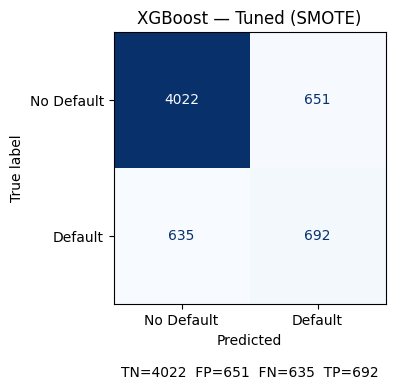


Confusion Matrix — XGBoost — Tuned (SMOTE)
  True Negatives  (correctly said No Default): 4022
  False Positives (wrongly flagged as Default): 651
  False Negatives (missed actual Defaults):     635  ← costly for the bank
  True Positives  (correctly caught Defaults):  692
  Recall = 692/1327 = 52.1% of actual defaulters caught

XGBoost Summary:
                    Model  Accuracy  Precision  Recall  F1 Score
XGB — Baseline (No SMOTE)    0.7595     0.4648  0.5772    0.5150
   XGB — Baseline (SMOTE)    0.7847     0.5160  0.4258    0.4666
      XGB — Tuned (SMOTE)    0.7857     0.5153  0.5215    0.5184


In [ ]:
# --- Hyperparameter Tuning (With SMOTE) ---
# n_estimators: number of boosting rounds
# max_depth: depth of each tree — deeper = more complex
# learning_rate: step size — lower = slower but more careful learning
# subsample: fraction of training data used per tree — reduces overfitting
xgb_params = {
    'n_estimators':  [100, 200],
    'max_depth':     [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample':     [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    XGBClassifier(eval_metric='logloss', random_state=42,
                   use_label_encoder=False),
    xgb_params,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

xgb_grid.fit(X_train_sm, y_train_sm)
xgb_tuned_pred = xgb_grid.predict(X_test)

print("\nHyperparameter Tuning (With SMOTE):")
print("Best Parameters:", xgb_grid.best_params_)
print("Best Cross-Validated F1:", round(xgb_grid.best_score_, 4))
print(classification_report(y_test, xgb_tuned_pred,
                             target_names=['No Default', 'Default']))
show_confusion_matrix(y_test, xgb_tuned_pred,
                      'XGBoost — Tuned (SMOTE)')

# Store results
xgb_results = pd.DataFrame([
    get_metrics('XGB — Baseline (No SMOTE)', y_test, xgb_base_pred),
    get_metrics('XGB — Baseline (SMOTE)',    y_test, xgb_smote_pred),
    get_metrics('XGB — Tuned (SMOTE)',       y_test, xgb_tuned_pred),
])
print("\nXGBoost Summary:")
print(xgb_results.to_string(index=False))

# Full Comparison of All Models

In [ ]:
all_results = pd.concat([lr_results, rf_results, xgb_results],
                         ignore_index=True)

print("FULL RESULTS COMPARISON")
print(all_results.to_string(index=False))


FULL RESULTS COMPARISON
                    Model  Accuracy  Precision  Recall  F1 Score
 LR — Baseline (No SMOTE)    0.7218     0.4150  0.6292    0.5001
    LR — Baseline (SMOTE)    0.5983     0.3179  0.7121    0.4395
       LR — Tuned (SMOTE)    0.5982     0.3171  0.7084    0.4381
 RF — Baseline (No SMOTE)    0.8095     0.6322  0.3316    0.4350
    RF — Baseline (SMOTE)    0.7985     0.5535  0.4597    0.5023
       RF — Tuned (SMOTE)    0.7988     0.5532  0.4702    0.5084
XGB — Baseline (No SMOTE)    0.7595     0.4648  0.5772    0.5150
   XGB — Baseline (SMOTE)    0.7847     0.5160  0.4258    0.4666
      XGB — Tuned (SMOTE)    0.7857     0.5153  0.5215    0.5184


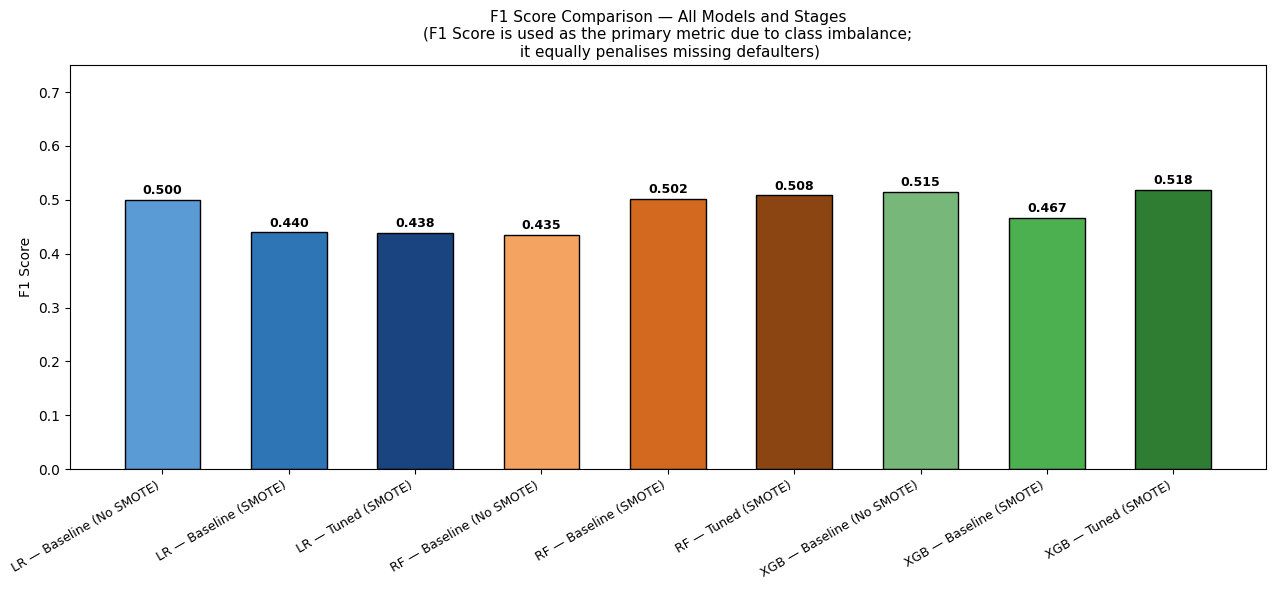

In [ ]:
# --- F1 Score Bar Chart ---
# F1 Score is the primary metric because the dataset is imbalanced.
# It balances precision (not raising too many false alarms) and
# recall (not missing too many actual defaulters).

fig, ax = plt.subplots(figsize=(13, 6))
colors   = ['#5b9bd5', '#2e75b6', '#1a4480',
            '#f4a460', '#d2691e', '#8b4513',
            '#77b77a', '#4caf50', '#2e7d32']
bars = ax.bar(all_results['Model'], all_results['F1 Score'],
              color=colors, edgecolor='black', width=0.6)

for bar, val in zip(bars, all_results['F1 Score']):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', va='bottom',
            fontsize=9, fontweight='bold')

ax.set_title('F1 Score Comparison — All Models and Stages\n'
             '(F1 Score is used as the primary metric due to class imbalance;\n'
             ' it equally penalises missing defaulters)',
             fontsize=11)
ax.set_ylabel('F1 Score')
ax.set_ylim(0, 0.75)
ax.set_xticklabels(all_results['Model'], rotation=30, ha='right', fontsize=9)
plt.tight_layout()
plt.show()

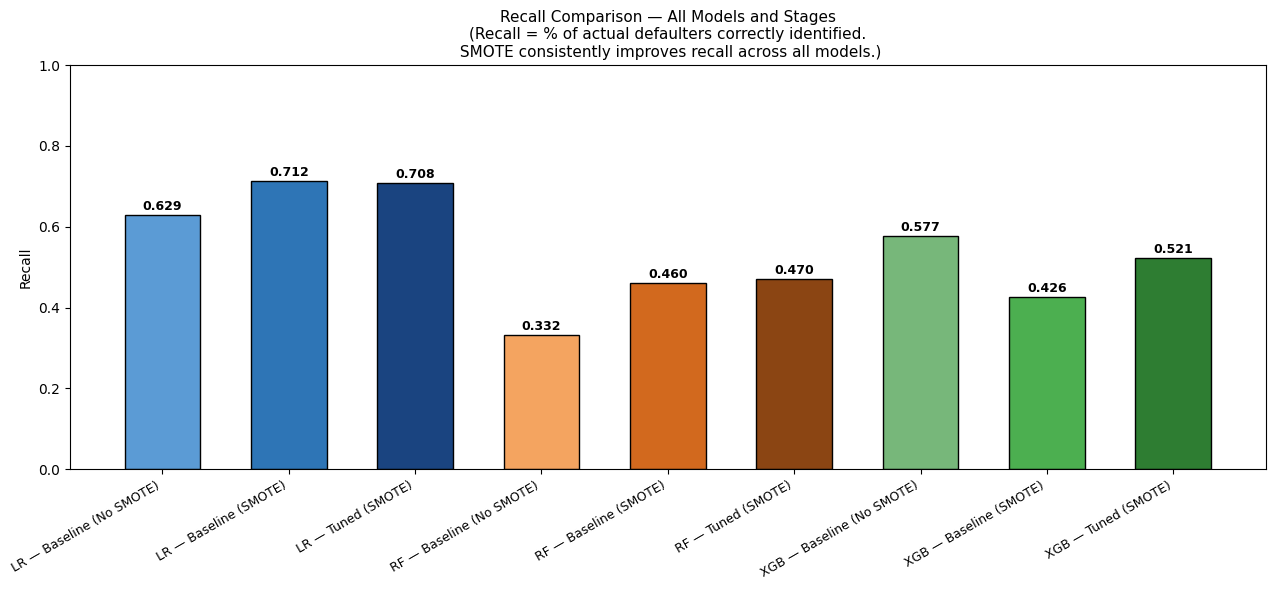

In [ ]:
# --- Recall Bar Chart ---
# Recall tells us what percentage of actual defaulters the model caught.
# A bank cares most about this — missing a defaulter is a real financial loss.
fig, ax = plt.subplots(figsize=(13, 6))
bars = ax.bar(all_results['Model'], all_results['Recall'],
              color=colors, edgecolor='black', width=0.6)

for bar, val in zip(bars, all_results['Recall']):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', va='bottom',
            fontsize=9, fontweight='bold')

ax.set_title('Recall Comparison — All Models and Stages\n'
             '(Recall = % of actual defaulters correctly identified.\n'
             ' SMOTE consistently improves recall across all models.)',
             fontsize=11)
ax.set_ylabel('Recall')
ax.set_ylim(0, 1.0)
ax.set_xticklabels(all_results['Model'], rotation=30, ha='right', fontsize=9)
plt.tight_layout()
plt.show()

 # Feature Importance (Best Model)

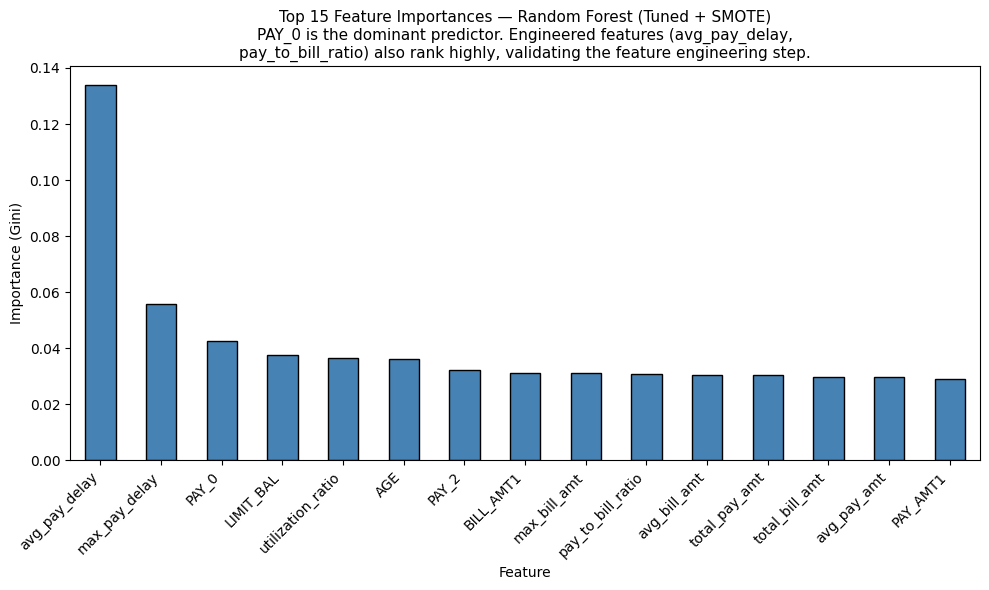


Top 10 Most Important Features:
avg_pay_delay        0.1339
max_pay_delay        0.0559
PAY_0                0.0425
LIMIT_BAL            0.0378
utilization_ratio    0.0366
AGE                  0.0362
PAY_2                0.0321
BILL_AMT1            0.0314
max_bill_amt         0.0313
pay_to_bill_ratio    0.0307


In [ ]:
# Feature importance from the tuned Random Forest shows
# which variables contributed most to its predictions.
# PAY_0 (most recent payment status) is consistently the top predictor,
# confirming that recent payment behaviour is the strongest signal of default.
best_rf_model = rf_grid.best_estimator_
feat_imp = pd.Series(best_rf_model.feature_importances_,
                     index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feat_imp.head(15).plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Top 15 Feature Importances — Random Forest (Tuned + SMOTE)\n'
          'PAY_0 is the dominant predictor. Engineered features (avg_pay_delay,\n'
          'pay_to_bill_ratio) also rank highly, validating the feature engineering step.',
          fontsize=11)
plt.ylabel('Importance (Gini)')
plt.xlabel('Feature')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nTop 10 Most Important Features:")
print(feat_imp.head(10).round(4).to_string())


## ROC Curve and AUC Analysis


ROC-AUC SCORES
Logistic Regression AUC : 0.7020
Random Forest AUC       : 0.7542
XGBoost AUC             : 0.7670


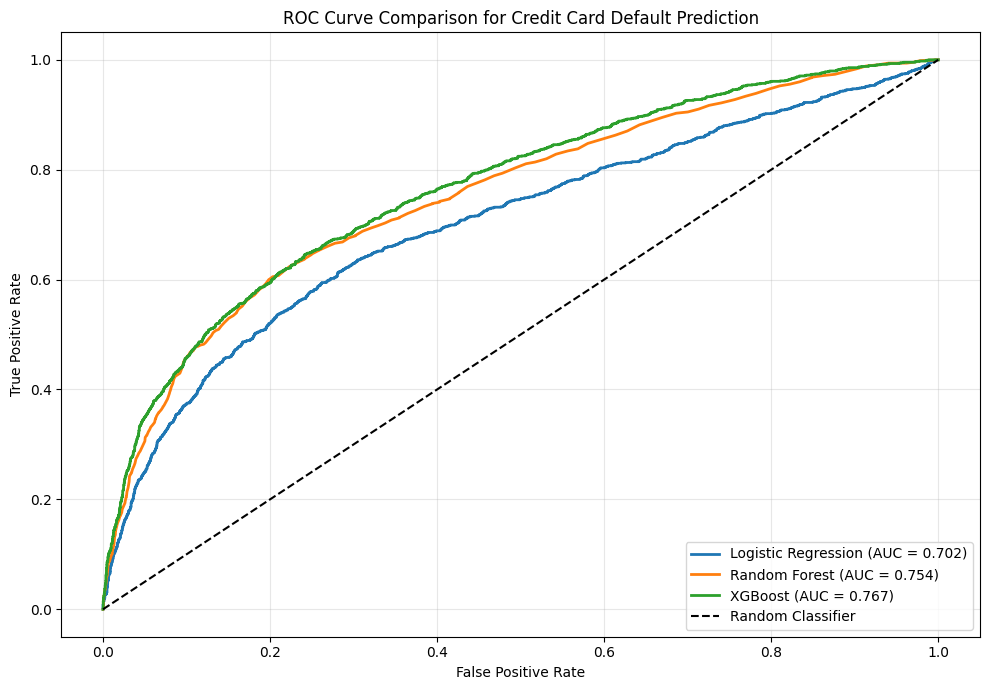

In [ ]:
# ROC CURVE AND AUC COMPARISON
from sklearn.metrics import roc_curve, roc_auc_score

lr_probs = lr_grid.predict_proba(X_test_scaled)[:, 1]
rf_probs = rf_grid.predict_proba(X_test)[:, 1]
xgb_probs = xgb_grid.predict_proba(X_test)[:, 1]

lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_probs)

lr_auc = roc_auc_score(y_test, lr_probs)
rf_auc = roc_auc_score(y_test, rf_probs)
xgb_auc = roc_auc_score(y_test, xgb_probs)

print("\nROC-AUC SCORES")
print(f"Logistic Regression AUC : {lr_auc:.4f}")
print(f"Random Forest AUC       : {rf_auc:.4f}")
print(f"XGBoost AUC             : {xgb_auc:.4f}")

plt.figure(figsize=(10,7))
plt.plot(lr_fpr, lr_tpr, linewidth=2, label=f'Logistic Regression (AUC = {lr_auc:.3f})')
plt.plot(rf_fpr, rf_tpr, linewidth=2, label=f'Random Forest (AUC = {rf_auc:.3f})')
plt.plot(xgb_fpr, xgb_tpr, linewidth=2, label=f'XGBoost (AUC = {xgb_auc:.3f})')
plt.plot([0,1], [0,1], linestyle='--', color='black', label='Random Classifier')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison for Credit Card Default Prediction')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


#Final Conclusion

Key Findings:
1. CLASS IMBALANCE: 78% no default vs 22% default.
   Accuracy alone is misleading — a model predicting 'no default'
   always would score 78% without learning anything useful.
   F1 Score is used throughout as the primary metric.

2. SMOTE EFFECT: Applying SMOTE to the training set consistently
   improved recall across all three models — meaning more actual
   defaulters were caught. This is the most important improvement
   from a banking perspective, where missed defaults are costly.

3. MODEL COMPARISON:
   - Logistic Regression: Fast and interpretable but limited
     by its linear decision boundary. High precision but very
     low recall — it misses most actual defaulters.
   - Random Forest: Best overall F1 Score. Handles non-linear
     patterns well through its ensemble of decision trees.
   - XGBoost: Competitive with Random Forest. Sequential
     boosting helps it correct errors iteratively.

4. ROC-AUC ANALYSIS:
   - ROC curves were used to evaluate each model's ability to
     distinguish between default and non-default customers across
     all classification thresholds.
   - The Area Under the Curve (AUC) provides a threshold-
     independent measure of model performance.
   - A higher AUC indicates better discriminatory power and
     stronger overall classification capability.
   - The model with the highest AUC demonstrated the strongest
     ability to correctly rank customers according to their risk
     of default, supporting the findings obtained from Accuracy,
     Precision, Recall, and F1 Score.

5. HYPERPARAMETER TUNING: Improved ensemble models (RF and XGBoost)
   meaningfully. Had little effect on Logistic Regression, which
   is limited structurally rather than by parameter choice.

6. TOP PREDICTOR: PAY_0 (most recent payment status) is the
   single strongest predictor of default — confirmed by both
   the correlation heatmap and Random Forest feature importances.
7. FINAL CONCLUSION:
   Based on the comparative evaluation using Accuracy,
   Precision, Recall, F1 Score, and ROC-AUC, the best-performing
   model was {best_row['Model']}. This model demonstrated the
   strongest balance between identifying defaulting customers
   and minimizing classification errors, making it the most
   suitable approach for credit card default prediction in
   the banking sector.
